# freeizng 1 18 24

In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

# co9 12122023 - models with different lags

In [2]:
session_path = '../data/co/co9/co9_12122023'
opto_session = MPOptoClass(session_path, laser_channel=3)

love


In [3]:
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepBinParamsco9_10sw.pickle')

In [4]:
climb_h_wpl = []
laser_h_wpl = []
climb_r2s = []
climbtest_r2s = []
laser_r2s = []
lasertest_r2s = []
nlags = []
for o in output:
    climb_h_wpl.append(opto_session.weights_per_lag(h=o[0], nlags=o[4]))
    laser_h_wpl.append(opto_session.weights_per_lag(h=o[1], nlags=o[4]))
    temp = o[2]
    climb_r2s.append(temp[0])
    climbtest_r2s.append(temp[1])
    temp = o[3]
    laser_r2s.append(temp[0])
    lasertest_r2s.append(temp[1])
    nlags.append(o[4])

    

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


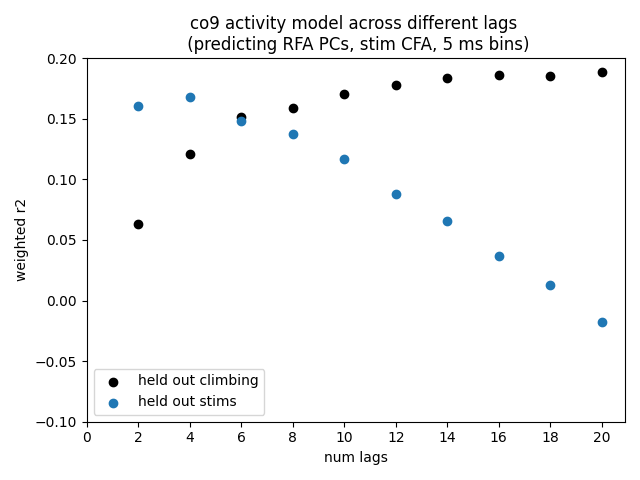

In [5]:
fig0, ax0 = plt.subplots()
ax0.scatter(nlags, climb_r2s, color='black', label='held out climbing')
ax0.scatter(nlags, climbtest_r2s, color='tab:blue', label='held out stims')
ax0.legend()
#ax0.scatter(nlags, laser_r2s, color='gray')
#ax0.scatter(nlags, lasertest_r2s, color='tab:green')
ax0.set_xticks(np.arange(0, 22, 2))
ax0.set_title('co9 activity model across different lags \n (predicting RFA PCs, stim CFA, 5 ms bins)')
ax0.set_ylabel('weighted r2')
ax0.set_xlabel('num lags')
ax0.set_ylim([-.1, .2])
fig0.tight_layout()

# including stims in training

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


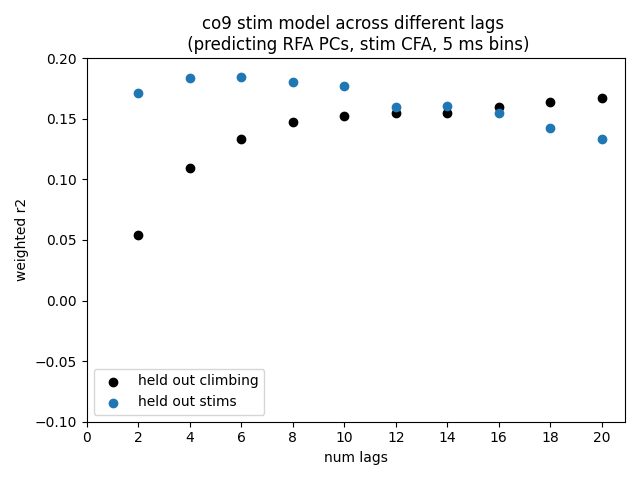

In [6]:
fig01, ax01 = plt.subplots()
#ax01.scatter(nlags, climb_r2s, color='black',  alpha=.2)
#ax01.scatter(nlags, climbtest_r2s, color='tab:blue',  alpha=.2)
ax01.scatter(nlags, laser_r2s, label='held out climbing', color='black')
ax01.scatter(nlags, lasertest_r2s, label='held out stims', color='tab:blue')
ax01.set_xticks(np.arange(0, 22, 2))
ax01.set_ylim([-.1, .2])
ax01.legend()
ax01.set_title('co9 stim model across different lags \n (predicting RFA PCs, stim CFA, 5 ms bins)')
ax01.set_ylabel('weighted r2')
ax01.set_xlabel('num lags')
fig01.tight_layout()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


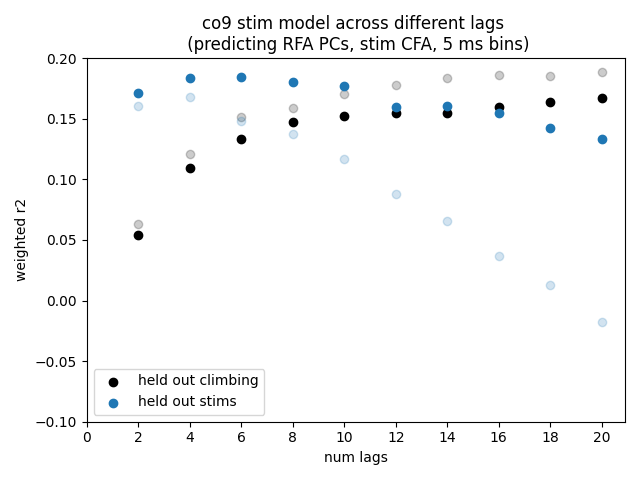

In [7]:
fig02, ax02 = plt.subplots()
ax02.scatter(nlags, climb_r2s, color='black',  alpha=.2)
ax02.scatter(nlags, climbtest_r2s, color='tab:blue',  alpha=.2)
ax02.scatter(nlags, laser_r2s, label='held out climbing', color='black')
ax02.scatter(nlags, lasertest_r2s, label='held out stims', color='tab:blue')
ax02.set_xticks(np.arange(0, 22, 2))
ax02.set_ylim([-.1, .2])
ax02.legend()
ax02.set_title('co9 stim model across different lags \n (predicting RFA PCs, stim CFA, 5 ms bins)')
ax02.set_ylabel('weighted r2')
ax02.set_xlabel('num lags')
fig02.tight_layout()

# how do stims affect weights in each lag

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


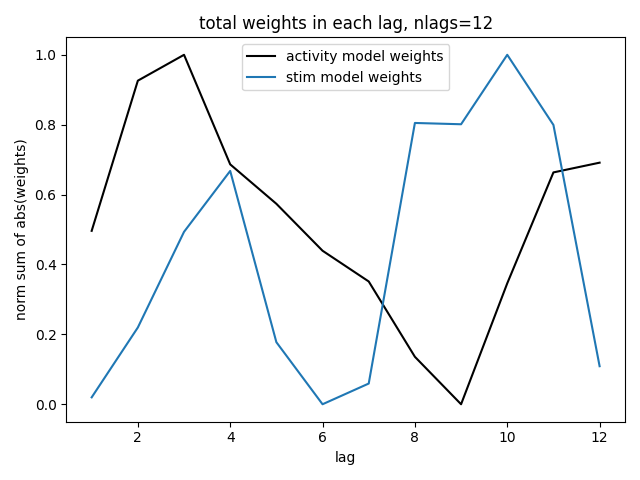

In [22]:
fig03, ax03 = plt.subplots()
temp = np.arange(2, 22,2)
model_num = 5
num_lags = temp[model_num]
x = np.arange(num_lags) + 1
ax03.set_title(f'total weights in each lag, nlags={num_lags}')
ax03.plot(x, climb_h_wpl[model_num].T, color='black', label='activity model weights')
ax03.plot(x, laser_h_wpl[model_num].T, color='tab:blue', label='stim model weights')
ax03.set_xlabel('lag')
ax03.set_ylabel('norm sum of abs(weights)')
ax03.legend()
fig03.tight_layout()

# how do stims affect the range of well fit models

In [10]:
session = MPOptoClass('../data/co/co9/co9_12122023', laser_channel=3) 
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegsSW_9log_co9.pickle')

love


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


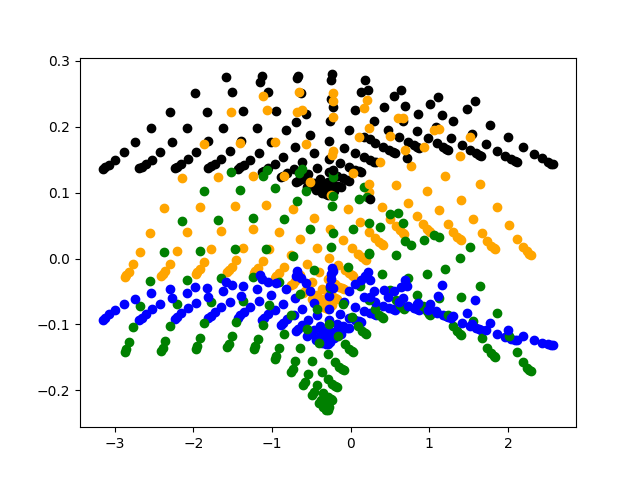

In [23]:
fig, ax = plt.subplots()
ratio_list = []
ratio2_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []

raw_weights_list = []

tlaser_score_list =[]
tctrl_score_list = []
for idx, o in enumerate(output):
    h = o[0]
    h_stim = o[3]
    laser_score = o[1]
    ctrl_score = o[2]
    
    tlaser_score = o[4]
    tctrl_score = o[5]
    
    temp = session.weights_per_region(h)
    ratio = np.log10(temp[0]/temp[1])
    
    if min(temp) < .01:
        continue
    
    
    
    raw_weights_list.append(temp)
    
    temp2 = session.weights_per_region(h_stim)
    
    if min(temp2) < .01:
        continue
    ratio2 = np.log10(temp2[0]/temp2[1])
    
    
    ratio_list.append(ratio)
    ratio2_list.append(ratio2)
    h_list.append(h)
    laser_score_list.append(laser_score)
    ctrl_score_list.append(ctrl_score)
    tlaser_score_list.append(tlaser_score)
    tctrl_score_list.append(tctrl_score)
    
    ax.scatter(ratio, o[1], color='blue')
    ax.scatter(ratio, o[2], color='black')
    ax.scatter(ratio2, o[4], color='green')
    ax.scatter(ratio2, o[5], color='orange')
#ax.legend()

In [24]:
reg_terms = np.logspace(0,9,20)
reg_combos = list(product(reg_terms, reg_terms))
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
tlaser_score_list = np.array(tlaser_score_list)
tctrl_score_list = np.array(tctrl_score_list)
raw_weights_list = np.squeeze(np.array(raw_weights_list))
ratio_list = np.array(ratio_list)
ratio2_list = np.array(ratio2_list)
nada, bin_ratio_edges = np.histogram(ratio_list, bins=10)

laser_score_keep = []
ctrl_score_keep = []
tlaser_score_keep = []
tctrl_score_keep = []
ratio_keep = []
ratio2_keep = []
raw_weights = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    
    keep = np.argmax(tlaser_score_list[indices])
    temp1 = tlaser_score_list[indices]
    temp2 = temp1[keep]
    tlaser_score_keep.append(temp2)
    
    temp1 = tctrl_score_list[indices]
    temp2 = temp1[keep]
    tctrl_score_keep.append(temp2)
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
    temp1 = raw_weights_list[indices, :]
    temp2 = temp1[keep, :]
    raw_weights.append(temp2)
    
        
    temp1 = ratio2_list[indices]
    temp2 = temp1[keep]
    ratio2_keep.append(temp2)
    
    #indices = np.argwhere(np.logical_and(condition1,condition2))
    #keep = np.argmax(ctrl_score_list[indices])
    
    temp1 = laser_score_list[indices]
    temp2 = temp1[keep]
    laser_score_keep.append(temp2) 
    
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 
    

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


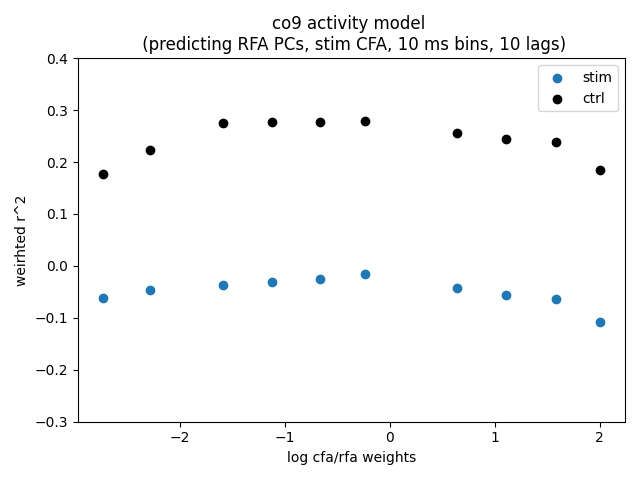

In [25]:
fig2, ax2 = plt.subplots()
ax2.scatter(ratio_keep, laser_score_keep, c='tab:blue', label='stim')
ax2.scatter(ratio_keep, ctrl_score_keep, c='black', label='ctrl')
#ax2[1].scatter(ratio2_keep, tlaser_score_keep, c='tab:blue', label='stim')
#ax2[1].scatter(ratio2_keep, tctrl_score_keep, c='black', label='ctrl')
#ax2[1].scatter(ratio_keep, laser_score_keep, c='tab:blue', label='activity model stim', alpha=0.2)
#ax2[1].scatter(ratio_keep, ctrl_score_keep, c='black', label='activity model ctrl', alpha=0.2)
ax2.set_ylabel('weirhted r^2')
#ax2[1].set_ylabel('weirhted r^2')
ax2.set_xlabel('log cfa/rfa weights')
#ax2.axhline(best_CFA_score, c='tab:blue', linestyle='--', label='CFA only r2 score')
#ax2.axhline(best_RFA_score, c= 'tab:red', linestyle='--', label='RFA only r2 score')
ax2.legend()
#ax2[1].legend()
ax2.set_title('co9 activity model \n (predicting RFA PCs, stim CFA, 10 ms bins, 10 lags)')
#ax2[1].set_title('co9, activity + stims model')


ax2.set_ylim(-.3, .4)
fig2.tight_layout()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


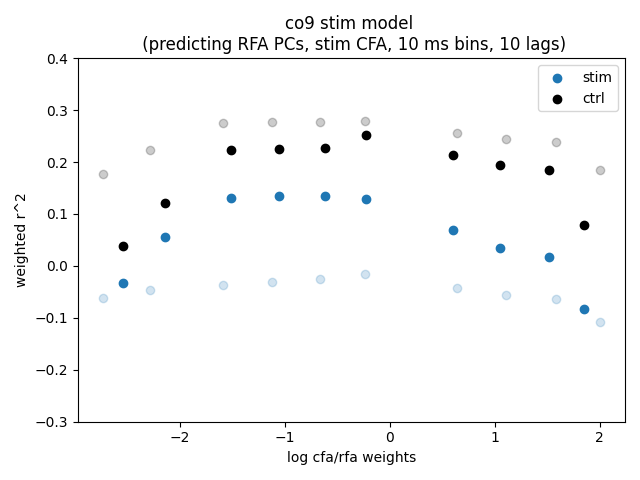

In [26]:
fig3, ax3 = plt.subplots()
ax3.scatter(ratio_keep, laser_score_keep, c='tab:blue', alpha=0.2)
ax3.scatter(ratio_keep, ctrl_score_keep, c='black', alpha=0.2)
ax3.scatter(ratio2_keep, tlaser_score_keep, c='tab:blue', label='stim')
ax3.scatter(ratio2_keep, tctrl_score_keep, c='black', label='ctrl')
ax3.set_ylabel('weighted r^2')
ax3.set_ylabel('weighted r^2')
ax3.set_xlabel('log cfa/rfa weights')
ax3.legend()
ax3.legend()
ax3.set_title('co9 stim model \n (predicting RFA PCs, stim CFA, 10 ms bins, 10 lags)')


ax3.set_ylim(-.3, .4)
fig3.tight_layout()

# chaos after here

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


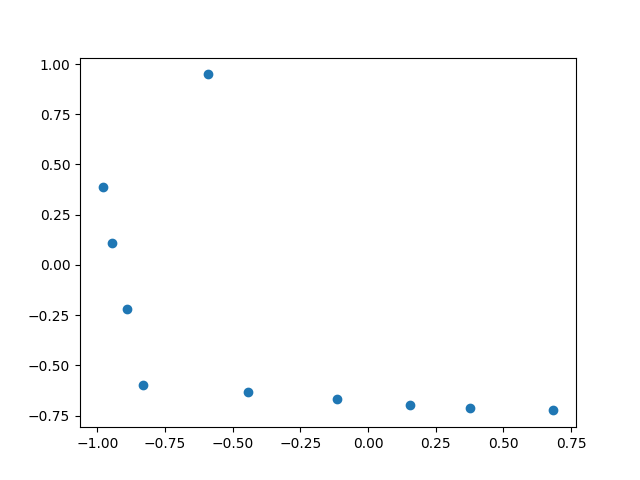

In [207]:
raw_weights_array = np.squeeze(np.array(raw_weights))
x=np.arange(len(raw_weights_array))
fig4, ax4 = plt.subplots()

ax4.scatter(np.log10(raw_weights_array[:,0]), np.log10(raw_weights_array[:,1]))

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


NameError: name 'cfa_weight' is not defined

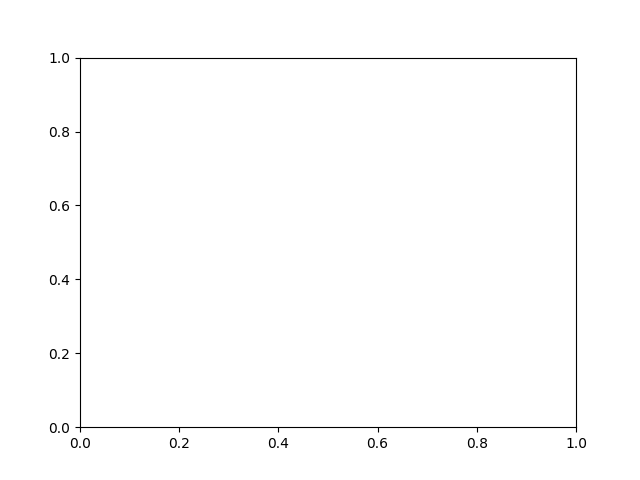

In [164]:
fig, ax = plt.subplots()
ax.scatter(cfa_weight, rfa_weight)
ax.set_xlabel('log(cfa weight')
ax.set_ylabel('log(rfa wieght')

In [1]:
reg_terms = np.power(np.linspace(-20,40,15), 3)
reg_terms = reg_terms + np.abs((reg_terms[0]))
reg_combos = list(product(reg_terms, reg_terms))

NameError: name 'np' is not defined

In [64]:
len(reg_combos)

225

In [67]:
reg_terms

array([    0.        ,  4119.5335277 ,  6507.28862974,  7635.56851312,
        7976.67638484,  8002.9154519 ,  8186.58892128,  9000.        ,
       10915.45189504, 14405.24781341, 19941.6909621 , 27997.0845481 ,
       39043.73177843, 53553.93586006, 72000.        ])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


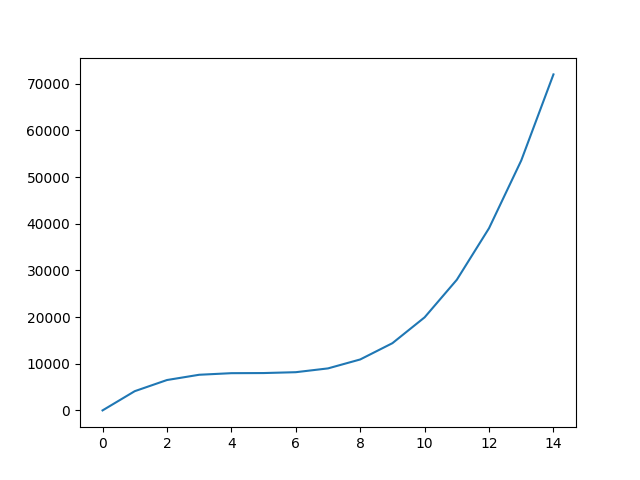

In [68]:
fig, ax = plt.subplots()
ax.plot(reg_terms)

/tmp/ipykernel_13675/2885100641.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figg, ax = plt.subplots()
/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


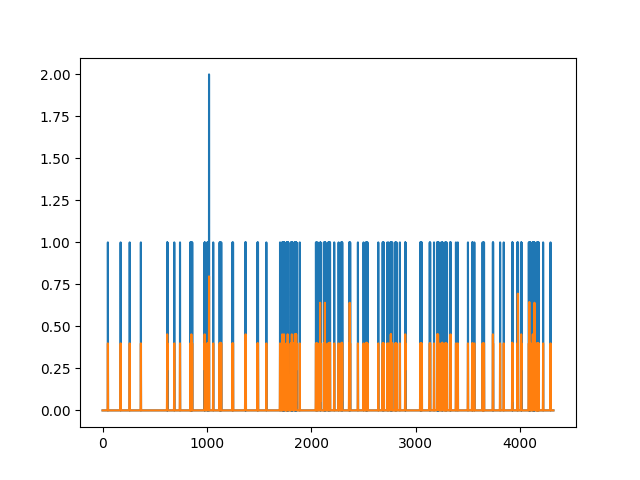

In [73]:
cfa, rfa = opto_session.binner(bounds=laser_bounds, binsize=5, concat=True)
cfa_s, rfa_s = opto_session.smoother(bounds=laser_bounds, binsize=5, sigma=5, concat=True, smooth_type='future')

figg, ax = plt.subplots()
ax.plot(cfa[:,0])
ax.plot(cfa_s[:,0])


In [43]:
num_PCs=50
pre=100
#(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
#all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

laser_bounds = copy.deepcopy(opto_session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8)

omitTestLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, test_lasers)
omitAllLaserBounds = omitBoundInBounds(omitTestLaserBounds, train_lasers)

(climb_nlags_PCA, climb_cut_PCA), climb_PCObjs = opto_session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=10, nlags=10, num_PCs=num_PCs)
climb_RFA_PCA = climb_cut_PCA[:, num_PCs:]

sw = opto_session.getSWs(bigBound=omitTestLaserBounds, smallBound=train_lasers, sw_weight=25, binsize=10, nlags=10)

(laser_nlags_PCA, laser_cut_PCA), laser_PCObjs = opto_session.format_nlags_PCA(bounds=omitTestLaserBounds, binsize=10, nlags=10, num_PCs=num_PCs)
laser_RFA_PCA = laser_cut_PCA[:, num_PCs:]


climbtest_nlags_PCA, climbtest_cut_PCA = opto_session.transformat(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=10, nlags=10)
climbtest_RFA_PCA = climbtest_cut_PCA[:, num_PCs:]
lasertest_nlags_PCA, lasertest_cut_PCA = opto_session.transformat(laser_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=10, nlags=10)
lasertest_RFA_PCA = lasertest_cut_PCA[:, num_PCs:]



bounds too small for history
bounds too small for history


In [44]:
climb_true_y, climb_predic_y, climb_h = wiener_kfolds(climb_nlags_PCA, climb_RFA_PCA, c=(2,5), sweep='log') 
laser_true_y, laser_predic_y, laser_h = wiener_kfolds(laser_nlags_PCA, laser_RFA_PCA, c=(2,5), sw = sw, sweep='log') 

climbtest_predic_y = test_wiener_filter(climbtest_nlags_PCA, climb_h)
lasertest_predic_y = test_wiener_filter(lasertest_nlags_PCA, laser_h)

climb_xval_score = weighted_r2(climb_true_y, climb_predic_y)
laser_xval_score = weighted_r2(laser_true_y, laser_predic_y)

climb_test_score = weighted_r2(climbtest_RFA_PCA, climbtest_predic_y)
laser_test_score = weighted_r2(lasertest_RFA_PCA, lasertest_predic_y)

print(climb_xval_score, laser_xval_score)

print(climb_test_score, laser_test_score)



0it [00:00, ?it/s]

best_c: 21544.346900318822


1it [00:07,  7.91s/it]

best_c: 21544.346900318822


2it [00:15,  7.95s/it]

...

best_c: 46415.888336127726


3it [00:26,  8.92s/it]

best_c: 46415.888336127726


4it [00:35,  8.91s/it]

0.24318058407282353 0.1685907364437181
-0.026134609338894634 0.12812695440230176


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


NameError: name 'sw_climb_score' is not defined

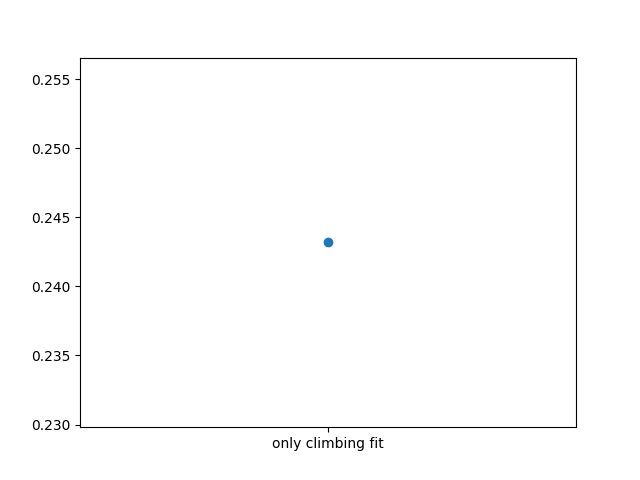

In [42]:
fig22, ax22 = plt.subplots()
ax22.scatter(['only climbing fit'], climb_xval_score, color='tab:blue', label='trained on only climbing')
#ax22.scatter(['with stims fit'], laser_xval_score, color='tab:orange', label='trained with stims')
ax22.scatter(['with weighted stims fit'], sw_climb_score, color='tab:green')
ax22.scatter(['only climbing test'], climb_test_score, color='tab:blue')
#ax22.scatter(['with stims test'], laser_test_score, color='tab:orange')
ax22.scatter(['with weighted stims test'], sw_test_score, color='tab:green')
ax22.set_ylabel('weighted_r2')
ax22.set_title('co9 121323 w/ laser training vs without, ~150 laserse')
fig22.tight_layout()
fig22.savefig('with without training.png')

In [ ]:
print(opto_session.weights_per_region(sw_h, num_CFA=num_PCs))

In [ ]:
print(opto_session.weights_per_region(climb_h, num_CFA=num_PCs))

In [ ]:
print(len(laser_bounds))

# small models with a drop of smoothing

In [33]:
session_path = '../data/co/co9/co9_12122023'
opto_session = MPOptoClass(session_path, laser_channel=3)
pre=
num_PCs = 50

#(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
#all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

laser_bounds = copy.deepcopy(opto_session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
ctrl_bounds = copy.deepcopy(opto_session.laser['ctrl_bounds'])
ctrl_bounds[:,0] = ctrl_bounds[:,0] - pre
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8)

omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, laser_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)

(climb_nlags_PCA, nada), climb_PCObjs = opto_session.format_nlags_PCA_smooth(bounds=omitLaserBounds, binsize=5, nlags=10, 
                                                                                      smooth_type = 'causal', sigma=5, num_PCs=num_PCs)

(nada, climb_cut_PCA), nada = opto_session.format_nlags_PCA_smooth(bounds=omitLaserBounds, binsize=5, nlags=10,smooth_type='future', sigma=5,
                                                                   num_PCs=num_PCs)
climb_RFA_PCA = climb_cut_PCA[:, num_PCs:]


climb_true_y, climb_predic_y, climb_h = wiener_kfolds(climb_nlags_PCA, climb_RFA_PCA, c=(2,5), sweep='log') 

climbtest_nlags_PCA, nada = opto_session.transformat_smooth(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=5, nlags=10, sigma=5, smooth_type='causal')
nada, climbtest_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=5, nlags=10, sigma=5, smooth_type='future')

climbtest_RFA_PCA = climbtest_cut_PCA[:, num_PCs:]

climbctrl_nlags_PCA, nada = opto_session.transformat_smooth(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=5, nlags=10, sigma=5, smooth_type='causal')
nada, climbctrl_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=5, nlags=10, sigma=5, smooth_type='future')
climbctrl_RFA_PCA = climbctrl_cut_PCA[:, num_PCs:]

climbtest_predic_y = test_wiener_filter(climbtest_nlags_PCA, climb_h)
climbctrl_predic_y = test_wiener_filter(climbctrl_nlags_PCA, climb_h)
climb_ctrl_score = weighted_r2(climbctrl_RFA_PCA, climbctrl_predic_y)
climb_test_score = weighted_r2(climbtest_RFA_PCA, climbtest_predic_y)

print(climb_ctrl_score, climb_test_score)



love
bounds too small for history
bounds too small for history


0it [00:00, ?it/s]

None
best_c: 2154.4346900318824


1it [00:14, 14.65s/it]

None
best_c: 4641.588833612777


...

None
best_c: 4641.588833612777


3it [00:44, 14.70s/it]

None
best_c: 4641.588833612777


4it [00:58, 14.69s/it]


0.2071953285699444 0.05320311015281526


In [9]:
session_path = '../data/co/co9/co9_12122023'
opto_session = MPOptoClass(session_path, laser_channel=3)
num_PCs = 50
binsize=5
nlags=2
sigma=5
pre=nlags*binsize

#(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
#all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

laser_bounds = copy.deepcopy(opto_session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
ctrl_bounds = copy.deepcopy(opto_session.laser['ctrl_bounds'])
ctrl_bounds[:,0] = ctrl_bounds[:,0] - pre
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8, random_state=1)

omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, laser_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)

(climb_nlags_PCA, nada), climb_PCObjs = opto_session.format_nlags_PCA(bounds=omitLaserBounds, binsize=binsize, nlags=nlags,
                                                                      num_PCs=num_PCs)

(nada, climb_cut_PCA), nada = opto_session.format_nlags_PCA_smooth(bounds=omitLaserBounds, binsize=binsize, nlags=nlags,smooth_type='future', sigma=sigma,
                                                                   num_PCs=num_PCs)
climb_RFA_PCA = climb_cut_PCA[:, num_PCs:]


climb_true_y, climb_predic_y, climb_h = wiener_kfolds(climb_nlags_PCA, climb_RFA_PCA, c=(2,5), sweep='log') 

climbtest_nlags_PCA, nada = opto_session.transformat(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=binsize, nlags=nlags)
nada, climbtest_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=binsize, nlags=nlags, sigma=sigma, smooth_type='future')

climbtest_RFA_PCA = climbtest_cut_PCA[:, num_PCs:]

climbctrl_nlags_PCA, nada = opto_session.transformat(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags)
nada, climbctrl_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags, sigma=sigma, smooth_type='future')
climbctrl_RFA_PCA = climbctrl_cut_PCA[:, num_PCs:]

climbtest_predic_y = test_wiener_filter(climbtest_nlags_PCA, climb_h)
climbctrl_predic_y = test_wiener_filter(climbctrl_nlags_PCA, climb_h)
climb_ctrl_score = weighted_r2(climbctrl_RFA_PCA, climbctrl_predic_y)
climb_test_score = weighted_r2(climbtest_RFA_PCA, climbtest_predic_y)

print(climb_ctrl_score, climb_test_score)



love


0it [00:00, ?it/s]

None


1it [00:01,  1.77s/it]

best_c: 2154.4346900318824
None


...

3it [00:05,  1.76s/it]

best_c: 2154.4346900318824
None


4it [00:07,  1.76s/it]

best_c: 2154.4346900318824


0.12482205789973097 0.06865833101003696


In [11]:
omitTestLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, test_lasers)
omitTestLaserBounds = omitBoundInBounds(omitTestLaserBounds, ctrl_bounds)
omitTestLaserBounds = minimumBoundSize(omitTestLaserBounds)

sw = opto_session.getSWs(omitTestLaserBounds, train_lasers, sw_weight=25, binsize=5, nlags=4)
#omitAllLaserBounds = omitBoundInBounds(omitTestLaserBounds, train_lasers)

(laser_nlags_PCA, nada), laser_PCObjs = opto_session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, binsize=5, nlags=4, 
                                                                                      smooth_type = 'causal', sigma=5, num_PCs=num_PCs)

(nada, laser_cut_PCA), nada = opto_session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, binsize=5, nlags=4,smooth_type='future', sigma=5,
                                                                   num_PCs=num_PCs)
laser_RFA_PCA = laser_cut_PCA[:, num_PCs:]
lasertest_nlags_PCA, lasertest_cut_PCA = opto_session.transformat_smooth(laser_PCObjs, bounds=test_lasers, num_PCs=num_PCs, sigma=5, smooth_type='causal', binsize=5, nlags=4)
lasertest_RFA_PCA = lasertest_cut_PCA[:, num_PCs:]

laserctrl_nlags_PCA, laserctrl_cut_PCA = opto_session.transformat_smooth(laser_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, sigma=5, smooth_type='causal', binsize=5, nlags=4)
laserctrl_RFA_PCA = laserctrl_cut_PCA[:, num_PCs:]


laser_true_y, laser_predic_y, laser_h = wiener_kfolds(laser_nlags_PCA, laser_RFA_PCA, c=(2,5), n_l2=4, sw=sw, sweep='log')


lasertest_predic_y = test_wiener_filter(lasertest_nlags_PCA, laser_h)
laserctrl_predic_y = test_wiener_filter(laserctrl_nlags_PCA, laser_h)



laser_test_score = weighted_r2(lasertest_RFA_PCA, lasertest_predic_y)
laser_ctrl_score = weighted_r2(laserctrl_RFA_PCA, laserctrl_predic_y)

print(laser_ctrl_score, laser_test_score)

0it [00:00, ?it/s]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


1it [00:02,  2.29s/it]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


2it [00:04,  2.28s/it]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


3it [00:06,  2.28s/it]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


4it [00:09,  2.29s/it]

0.17477829081792504 0.1562922364560629


In [ ]:
fig, ax = plt.subplots()
ax.plot(temp)
ax.plot(sw, color='red')

In [ ]:


print(weighted_r2(climb_true_y, climb_predic_y))
print(weighted_r2(laser_true_y, laser_predic_y))

In [ ]:
fig, ax = plt.subplots()
ax.plot(laser_true_y[:,0], color='black')
ax.plot(laser_predic_y[:,0], color='red')
